In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('/content/Telco_Customer_Churn_Cleaned.csv')

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [3]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [4]:
correlation = df.corr()['Churn'].sort_values(
    ascending=False
)

print(correlation)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
gender                                  -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


In [5]:
print(correlation.head(15))

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService                      0.011691
gender                           -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
OnlineBackup_Yes                 -0.082307
PaymentMethod_Mailed check       -0.090773
Name: Churn, dtype: float64


In [6]:
print(correlation.tail(15))

Partner                                -0.149982
Dependents                             -0.163128
TechSupport_Yes                        -0.164716
OnlineSecurity_Yes                     -0.171270
Contract_One year                      -0.178225
TotalCharges                           -0.199484
InternetService_No                     -0.227578
StreamingTV_No internet service        -0.227578
OnlineSecurity_No internet service     -0.227578
OnlineBackup_No internet service       -0.227578
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64


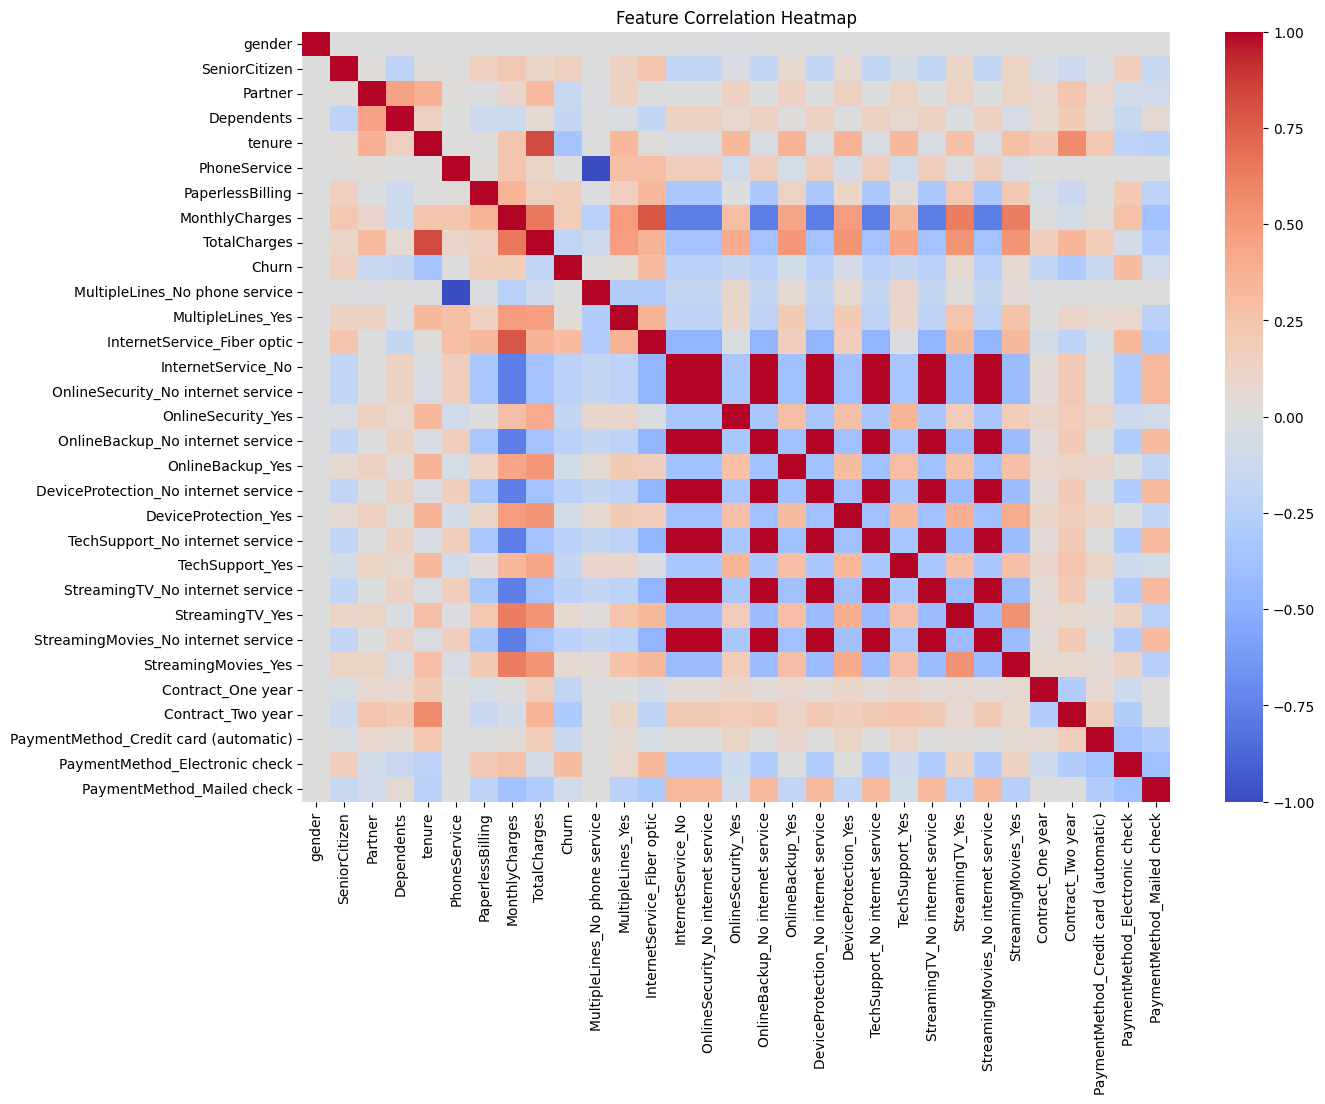

In [7]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [9]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [10]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
8,TotalCharges,0.200874
4,tenure,0.171621
7,MonthlyCharges,0.170378
28,PaymentMethod_Electronic check,0.039746
11,InternetService_Fiber optic,0.034320
26,Contract_Two year,0.028558
0,gender,0.027777
6,PaperlessBilling,0.025921
14,OnlineSecurity_Yes,0.024787
20,TechSupport_Yes,0.022988


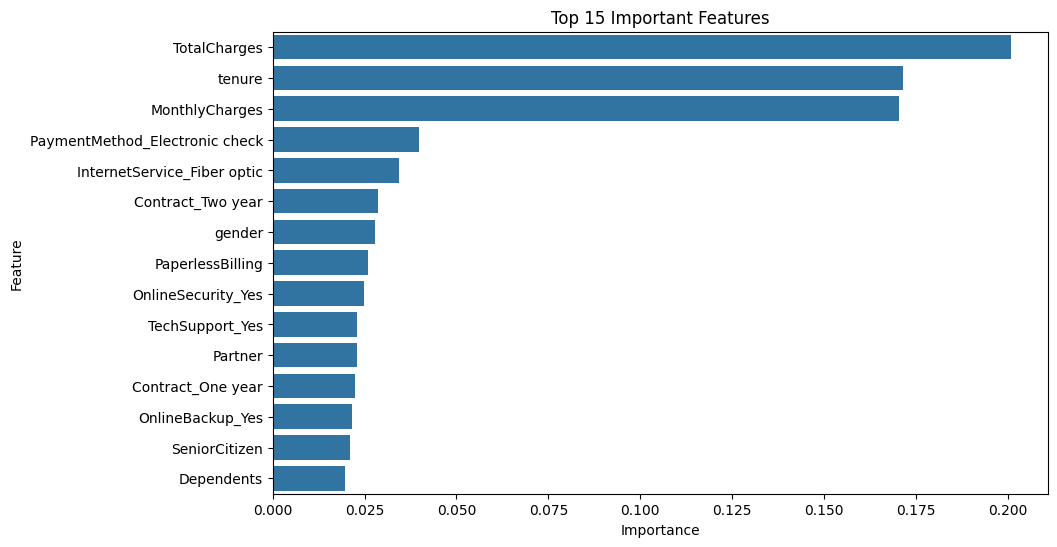

In [11]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top15
)

plt.title("Top 15 Important Features")
plt.show()

In [12]:
selected_features = importance.head(10)['Feature']

print(selected_features)

8                       TotalCharges
4                             tenure
7                     MonthlyCharges
28    PaymentMethod_Electronic check
11       InternetService_Fiber optic
26                 Contract_Two year
0                             gender
6                   PaperlessBilling
14                OnlineSecurity_Yes
20                   TechSupport_Yes
Name: Feature, dtype: object


In [13]:
X_selected = X[selected_features]

X_selected.head()

,TotalCharges,tenure,MonthlyCharges,PaymentMethod_Electronic check,InternetService_Fiber optic,Contract_Two year,gender,PaperlessBilling,OnlineSecurity_Yes,TechSupport_Yes
0,29.85,1,29.85,True,False,False,0,1,False,False
1,1889.50,34,56.95,False,False,False,1,0,True,False
2,108.15,2,53.85,False,False,False,1,1,True,False
3,1840.75,45,42.30,False,False,False,1,0,True,True
4,151.65,2,70.70,True,True,False,0,1,False,False


In [14]:
X_selected.to_csv(
    "Selected_Features.csv",
    index=False
)